**Lab2-DL: A1-CNN-intro.ipynb** (BMED365) | Priority: 1 (core)

_A brief introduction to CNNs for medical students – AI-assisted notebook_

[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/A1-CNN-intro.ipynb)

Last updated: 2025-12-21, A. Lundervold

Use the `bmed365-2026` conda environment or Google Colab




## MNIST: Deep Learning's "Hello World"

### What is the MNIST problem?

**MNIST** (Modified National Institute of Standards and Technology) is a dataset of **70,000 handwritten digits** (0-9), where each digit is a 28×28 pixel grayscale image. The task is simple: given an image, classify which digit it shows.

<div style="text-align: center; margin: 20px 0;">

| Example | Task |
|:--------:|:--------|
| ![0](https://upload.wikimedia.org/wikipedia/commons/2/27/MnistExamples.png) | Classify each 28×28 image into one of 10 classes (digits 0-9) |

*Examples from the MNIST dataset. Source: Wikipedia*
</div>

### Historical significance

MNIST has played a crucial role in the development of deep learning:

| Year | Milestone | Significance |
|----|---------|-----------|
| **1998** | Yann LeCun introduces LeNet-5 | First successful CNN on MNIST (~99% accuracy) |
| **2006** | Geoffrey Hinton relaunches deep learning | MNIST becomes standard benchmark |
| **2012** | AlexNet wins ImageNet | CNN architectures from MNIST scale up |
| **Today** | State-of-the-art: 99.8%+ | MNIST is now considered "solved", but remains pedagogically valuable |

> **"MNIST is to machine learning what 'Hello World' is to programming"**  
> – Francois Chollet, creator of Keras

### Why MNIST for medical students?

MNIST illustrates the **core principles** used in medical image analysis:

| MNIST concept | Medical application |
|---------------|---------------------|
| Image classification | X-ray: normal vs. pathological |
| Feature extraction | Detecting lesions, tumors, fractures |
| Convolutional filters | Edge detection in histopathology |
| Probability output | Differential diagnosis with confidence level |

### PyTorch: Our tool

**PyTorch** is an open-source deep learning framework developed by Meta AI. We use it because:

- 🔬 **Research-friendly**: Used by most AI laboratories
- 🏥 **Medical AI**: Standard in MONAI, fastMONAI, and other medical AI libraries  
- 📚 **Pedagogical**: Clear and readable code that shows what happens "under the hood"
- ⚡ **GPU acceleration**: Trains models quickly (also works without GPU)

```
Data flow in this notebook:

    MNIST images (28×28)
           │
           ▼
    ┌─────────────┐
    │   PyTorch   │  ← Data loading, tensors, training
    │   + CNN     │  ← Convolution, pooling, classification
    └─────────────┘
           │
           ▼
    Predicted digit (0-9)
```

---

*Let's now set up the environment and explore the data!*


## Understanding CNNs: A Medical Perspective

![Deep Learning hierarchical feature extraction](../assets/Waldrop-multiple-hidden-layers.png)

*__Figure:__ Deep learning builds on hierarchical feature extraction. From left: input image → early layers detect simple patterns (edges, light/dark) → intermediate layers combine these into complex structures → output provides classification. (Source: M. Waldrop, PNAS 2019)*

**Key concept:** Just as your brain processes visual information through hierarchical layers (from retina to visual cortex), a CNN learns to recognize patterns from simple to complex - from pixels to diagnoses.

Let's explain this neural network architecture using analogies from medical imaging and diagnostics:

### Overview
Think of this CNN as a medical specialist examining an X-ray image or a histology slide, progressively identifying more complex patterns before making a diagnosis.

### Layer-by-layer explanation (medical context):

1. **Input layer (28x28 image)**
   - Like receiving a grayscale microscope image or a small X-ray section
   - Corresponds to what you see under low magnification
   - Size: 28x28 pixels, one channel (like a grayscale histology image)

2. **First convolutional layer (Conv1)**
   - Like your first look through the microscope
   - Detects 32 different basic patterns (like cell edges, simple shapes)
   - Like having 32 different stains each highlighting different basic features
   - Output: 26x26x32 (32 different "views" of the image)

3. **First pooling layer (Pool1)**
   - Like taking a step back to get a broader overview
   - Retains the most important features while reducing details
   - Corresponds to when you zoom out on the microscope to see patterns
   - Reduces size to 13x13, but retains all 32 feature types

4. **Second convolutional layer (Conv2)**
   - Like looking for more complex patterns
   - Now looking for 64 different combinations of the basic features
   - Corresponds to how you combine basic findings into more complex diagnoses
   - Example: combines cell shape AND arrangement patterns

5. **Second pooling layer (Pool2)**
   - Further consolidation of findings
   - Like taking another step back to see broader patterns
   - Reduces to 5x5 size, but retains 64 feature types

6. **First fully connected layer (FC1)**
   - Like the initial diagnostic reasoning
   - Combines all observed features (1600 inputs → 128 neurons)
   - Corresponds to how you integrate multiple findings into differential diagnoses

7. **Final layer (FC2)**
   - The final diagnosis
   - 10 possible outcomes (like 10 possible diagnoses)
   - Each output represents the probability for each diagnosis

### Medical analogy for the process:
1. **Initial examination** (Input → Conv1)
   - Like your first look at a patient or sample
   - Identifies basic features (edges, shapes, textures)

2. **Pattern recognition** (Pool1 → Conv2)
   - Corresponds to recognizing patterns in pathology
   - Combines basic features into meaningful patterns

3. **Integration** (Pool2 → FC1)
   - Like combining multiple clinical findings
   - Builds a complete clinical picture

4. **Diagnosis** (FC2)
   - Final diagnostic decision
   - Probability for each possible diagnosis

### Clinical relevance:
- Corresponds to how you go from basic observations to final diagnosis
- Mirrors the medical decision-making process:
  1. Observe basic features
  2. Recognize patterns
  3. Combine findings
  4. Make a diagnosis

This is analogous to how you might examine a histology slide, where you start with basic cellular features and progressively integrate information to reach a diagnosis.


## Understanding the CNN Architecture Visualization: A Medical Perspective

This code creates a visual representation of our neural network, similar to how we might draw an anatomical diagram or a clinical workflow. Let's explain it in medical terms:

### Overall structure
Think of this as creating an anatomical atlas or a clinical pathway diagram:

```python
class CNNVisualizer:
    def __init__(self):
        # Color scheme like different tissue stains or medical diagrams
        self.colors = {
            'input': '#e2e8f0',    # Light gray for raw image (like unstained tissue)
            'conv': '#93c5fd',     # Blue for feature detection (like H&E staining)
            'pool': '#bfdbfe',     # Light blue for summary (like low magnification)
            'fc': '#fca5a5',       # Red for decision-making (like diagnostic areas)
            'text': '#1e293b'      # Dark gray for labels
        }
```

### Layer representation
Similar to how we represent different anatomical structures or diagnostic steps:

```python
layers = [
    # Like progression through microscope magnifications
    {'name': 'Input\n28x28x1', 'type': 'input'},      # Raw sample
    {'name': 'Conv1\n26x26x32', 'type': 'conv'},      # Initial features (like cell boundaries)
    {'name': 'Pool1\n13x13x32', 'type': 'pool'},      # Broader patterns (like tissue architecture)
    {'name': 'Conv2\n11x11x64', 'type': 'conv'},      # Complex features (like cell arrangements)
    {'name': 'Pool2\n5x5x64', 'type': 'pool'},        # Overall patterns
    {'name': 'FC\n128->10', 'type': 'fc'}             # Final diagnosis
]
```

### Visual elements

1. **Blocks (rectangular areas)**
   - Like different stages in a clinical workflow
   - Size indicates complexity (wider blocks = more complex processing)
   - Colors distinguish between different types of analysis (like different staining techniques)

2. **Arrows**
   - Like clinical pathways showing progression
   - Similar to how we draw step-by-step diagnostic processes
   - Shows information flow from observation to diagnosis

3. **Text labels**
   - Like anatomical labels or diagnostic criteria
   - Shows dimensions and transformations at each step
   - Helps track the progression of the analysis

4. **Legend**
   - Similar to how we label different tissue types in histology
   - Explains the meaning of different colors
   - Helps interpret the diagram

### Medical analogy
This visualization represents a process similar to:
1. **Input layer**: Initial patient presentation/sample
2. **Convolutional layers**: Detailed examination (like using different microscope objectives)
3. **Pooling layers**: Taking a step back to see broader patterns (like switching to lower magnification)
4. **Fully connected layers**: Integration of findings and diagnostic decision-making

### Clinical relevance
- The diagram flows from left to right like a clinical pathway
- Different colors represent different types of analysis (like different diagnostic tools)
- The progression mirrors medical decision-making:
  1. Initial observation
  2. Detailed examination
  3. Pattern recognition
  4. Diagnostic conclusion

This visualization helps understand how the CNN processes information, just as we visualize clinical workflows or anatomical structures in medical education.


## Understanding Convolution: A Medical Analogy

### Overview
Think of convolution as using a specialized filter or stain to highlight specific features in a medical image – just as different staining techniques reveal different tissue properties.

### The three main components (like a staining process):

| Component | Description | Medical analogy |
|-----------|-------------|-----------------|
| **Input (original image)** | 5×5 grid of pixel values | Like your original tissue sample or X-ray |
| **Convolution kernel (filter)** | 3×3 pattern that functions as a "stain" | Like choosing the right stain for the desired structure |
| **Output (result)** | Shows where the pattern was detected | Like the finished stained image |

### The process (like a staining protocol):

1. **Select window** – Take a 3×3 section (like focusing the microscope on an area)
2. **Pattern matching** – Multiply pixel values by kernel values (like dye uptake in tissue)
3. **Summarization** – Sum all products into one value (like measuring stain intensity)
4. **Move window** – Repeat for the entire image

### Clinical relevance
The convolution kernel is like choosing the right stain:
- **H&E** for general structure
- **Special stains** for specific components  
- **Immunostaining** for specific proteins

This visualization shows how CNNs can automatically detect patterns in medical images.


## Understanding Feature Maps: A Medical Analogy

### Overview
Think of this as viewing a medical image through different diagnostic filters:
- Different MRI sequences (T1, T2, FLAIR)
- Different staining techniques in pathology
- Different window settings on CT

### Layer-by-layer visualization:

| Layer | Visualization | Medical analogy |
|-------|---------------|-----------------|
| **Conv/Pool** | Feature maps (up to 8) | Like different stains highlighting different structures |
| **FC1** | Histogram of activations | Like distribution of laboratory values |
| **FC2** | Bar chart per class | Like differential diagnosis with confidence level |

### Clinical interpretation:

1. **Feature maps (Conv/Pool)**
   - Each "channel" highlights different patterns (edges, textures)
   - Like using different CT windows (bone, soft tissue, lung)

2. **FC1 distribution**
   - Shows spread of values with mean and standard deviation
   - Like reference values in a laboratory analysis

3. **FC2 classification**
   - Shows probability for each diagnosis
   - Like a differential diagnosis list with confidence level

### Clinical relevance
The visualization shows how AI "sees" images – from raw pixels to final diagnosis, just as we integrate multiple diagnostic tests to reach a conclusion.


## Understanding Classification Results: A Medical Analogy

### Overview
This is similar to how we interpret diagnostic tests to reach a final diagnosis – with both raw values and clinical interpretation.

### Two key views (like laboratory results):

| View | Description | Medical analogy |
|------|-------------|-----------------|
| **Raw activations (logits)** | Can be positive or negative | Like raw laboratory values before normalization |
| **Probabilities (softmax)** | Values between 0-1, sum to 100% | Like differential diagnosis with probabilities |

### Clinical statistics:

- **Predicted class**: Primary diagnosis
- **Confidence**: Diagnostic certainty (e.g., "90% certain this is...")
- **Entropy**: Measure of diagnostic uncertainty (high = more possible diagnoses)

### Medical analogy:

1. **Raw activations** → Like initial laboratory results that need interpretation
2. **Softmax conversion** → Like converting test values to clinical risk score
3. **Final interpretation** → Most likely diagnosis with confidence level

### Clinical relevance
The visualization shows how AI makes decisions – just as clinicians integrate multiple sources of evidence to reach a diagnosis with varying degrees of certainty.


## Python Classes: A Medical Analogy

Think of a Python class as a medical department at the hospital:

### Key concepts:

| Python concept | Medical analogy | Example |
|----------------|-----------------|---------|
| **Class** | Template for a department | `class Cardiology` |
| **Methods** | Standard procedures | `def take_ecg(self, patient)` |
| **Attributes** | Department resources | `self.equipment = ['ECG', 'Echo']` |
| **Instance** | A specific department | `heart_dept = Cardiology()` |

### Example:
```python
class EmergencyRoom:
    def __init__(self):
        self.beds = 20
        self.patients = []
    
    def admit_patient(self, patient):
        self.patients.append(patient)
    
    def treat(self, patient):
        diagnosis = self.examine(patient)
        return self.prescribe(diagnosis)
```

### Analogy
Just like a hospital department:
- Has standard procedures (methods)
- Manages its resources (attributes)
- Follows protocols (class structure)
- Can be replicated at different hospitals (instances)


In [1]:
# === Check runtime environment ===
# Detects whether the notebook is running in Google Colab or locally.
# This affects how data is loaded later.

try:
    import google.colab
    is_colab = True
    print("Running in Google Colab.")
except ImportError:
    is_colab = False
    print("Running locally (not Colab).")

Running locally (not Colab).


### Import libraries


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch
from matplotlib.gridspec import GridSpec
import torch
import torch.nn as nn
import os
import pandas as pd

In [3]:
# Create folder for MNIST data if it doesn't exist
os.makedirs('mnist_images', exist_ok=True)

csv_path = 'mnist_images/mnist_data_5000x785.csv'

# Check if the CSV file already exists
if os.path.exists(csv_path):
    print("Loading MNIST data from local CSV file...")
    mnist_data = pd.read_csv(csv_path)
else:
    print("Generating MNIST data from PyTorch (downloaded on first run)...")
    from torchvision import datasets
    import torchvision.transforms as transforms
    
    # Download MNIST via PyTorch
    mnist_train = datasets.MNIST(root='./data', train=True, download=True, 
                                  transform=transforms.ToTensor())
    mnist_test = datasets.MNIST(root='./data', train=False, download=True, 
                                 transform=transforms.ToTensor())
    
    # Convert to numpy and combine
    X_train = mnist_train.data.numpy().reshape(60000, -1) / 255.0
    X_test = mnist_test.data.numpy().reshape(10000, -1) / 255.0
    y_train = mnist_train.targets.numpy()
    y_test = mnist_test.targets.numpy()
    
    X = np.concatenate([X_train, X_test])
    y = np.concatenate([y_train, y_test])
    
    # Take a random sample of 5000 samples
    np.random.seed(42)
    indices = np.random.choice(len(X), 5000, replace=False)
    X_sample = X[indices]
    y_sample = y[indices]
    
    # Create DataFrame
    feature_names = [f'pixel_{i}' for i in range(784)]
    mnist_data = pd.DataFrame(X_sample, columns=feature_names)
    mnist_data['label'] = y_sample
    
    # Save to CSV for future use
    mnist_data.to_csv(csv_path, index=False)
    print(f"Data saved to {csv_path}")

print(f"MNIST data loaded: {mnist_data.shape[0]} samples, {mnist_data.shape[1]} columns")


Generating MNIST data from PyTorch (downloaded on first run)...


100%|██████████| 9.91M/9.91M [00:00<00:00, 10.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 285kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.13MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.03MB/s]


Data saved to mnist_images/mnist_data_5000x785.csv
MNIST data loaded: 5000 samples, 785 columns


### Explore the MNIST data

Let's look at some examples from the dataset we just loaded. This gives us an intuition for the task the network needs to solve.


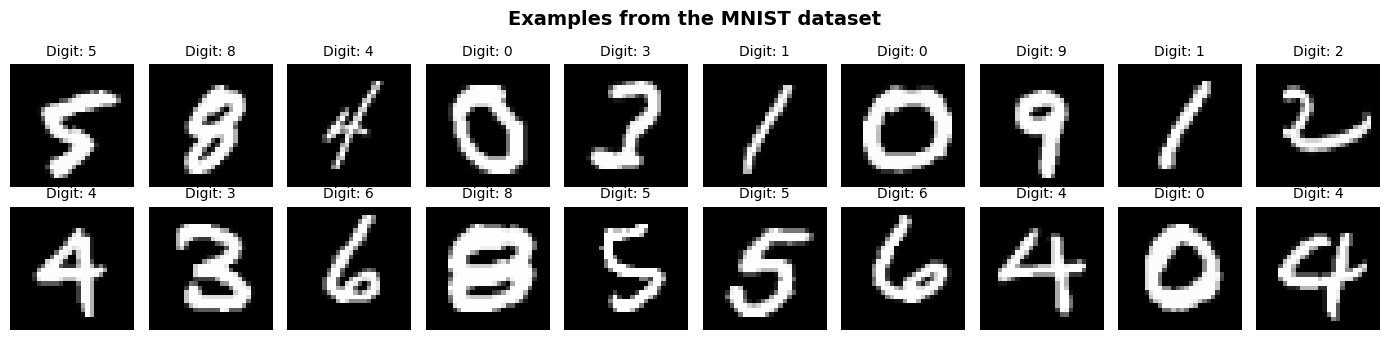

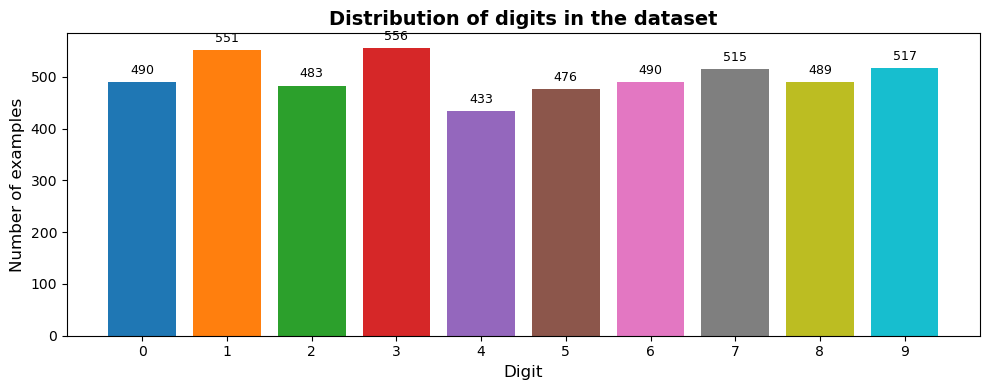


📊 The dataset contains 5000 images distributed across 10 digit classes.
📐 Each image is 28×28 = 784 pixels (grayscale, values 0-1).


In [4]:
# === Visualize MNIST examples ===

def show_mnist_examples(data, n_examples=20, random_selection=True):
    """
    Display a grid of MNIST digits.
    
    Args:
        data: DataFrame with pixel values and 'label' column
        n_examples: Number of examples to display
        random_selection: Whether to select examples randomly
    """
    n_rows = 2
    n_cols = n_examples // n_rows
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5))
    fig.suptitle('Examples from the MNIST dataset', fontsize=14, fontweight='bold')
    
    if random_selection:
        indices = np.random.choice(len(data), n_examples, replace=False)
    else:
        indices = range(n_examples)
    
    for idx, ax in enumerate(axes.flat):
        i = indices[idx]
        # Get pixel values (all columns except 'label')
        pixels = data.iloc[i, :-1].values.reshape(28, 28)
        label = int(data.iloc[i]['label'])
        
        ax.imshow(pixels, cmap='gray')
        ax.set_title(f'Digit: {label}', fontsize=10)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Also show the distribution of digits in the dataset
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    digit_distribution = data['label'].value_counts().sort_index()
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    bars = ax2.bar(digit_distribution.index, digit_distribution.values, color=colors)
    ax2.set_xlabel('Digit', fontsize=12)
    ax2.set_ylabel('Number of examples', fontsize=12)
    ax2.set_title('Distribution of digits in the dataset', fontsize=14, fontweight='bold')
    ax2.set_xticks(range(10))
    
    # Add count above each bar
    for bar, count in zip(bars, digit_distribution.values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
                str(count), ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 The dataset contains {len(data)} images distributed across 10 digit classes.")
    print(f"📐 Each image is {28}×{28} = 784 pixels (grayscale, values 0-1).")

# Run visualization
show_mnist_examples(mnist_data)


### Define classes and their functions

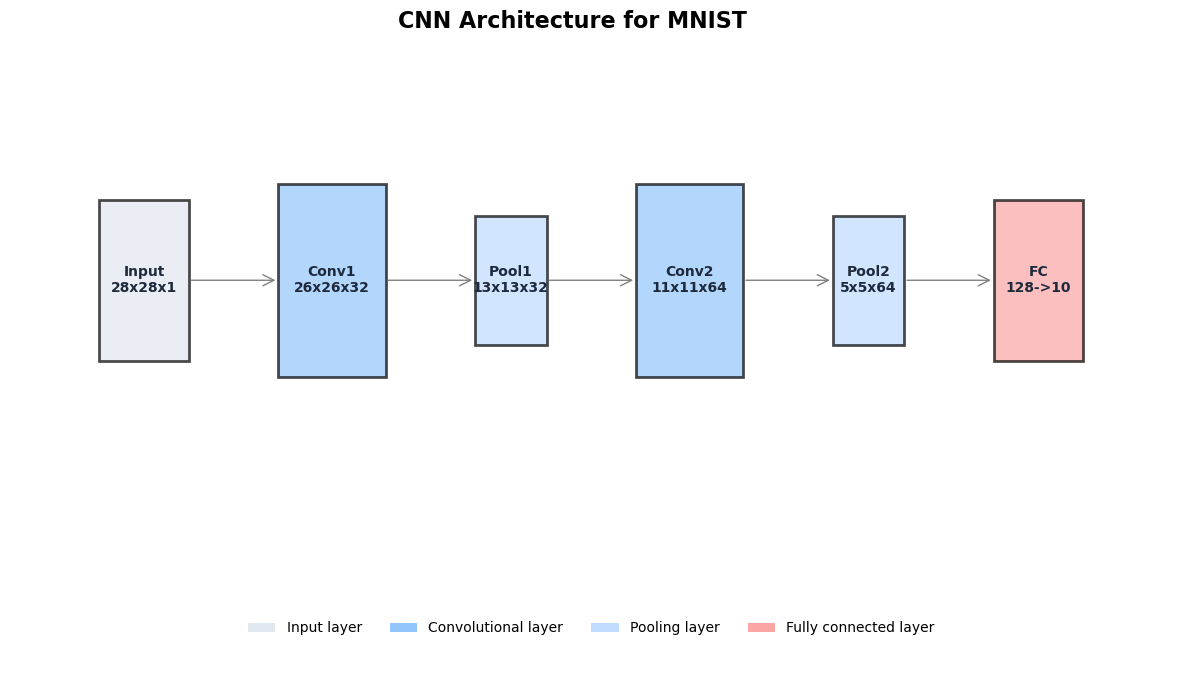

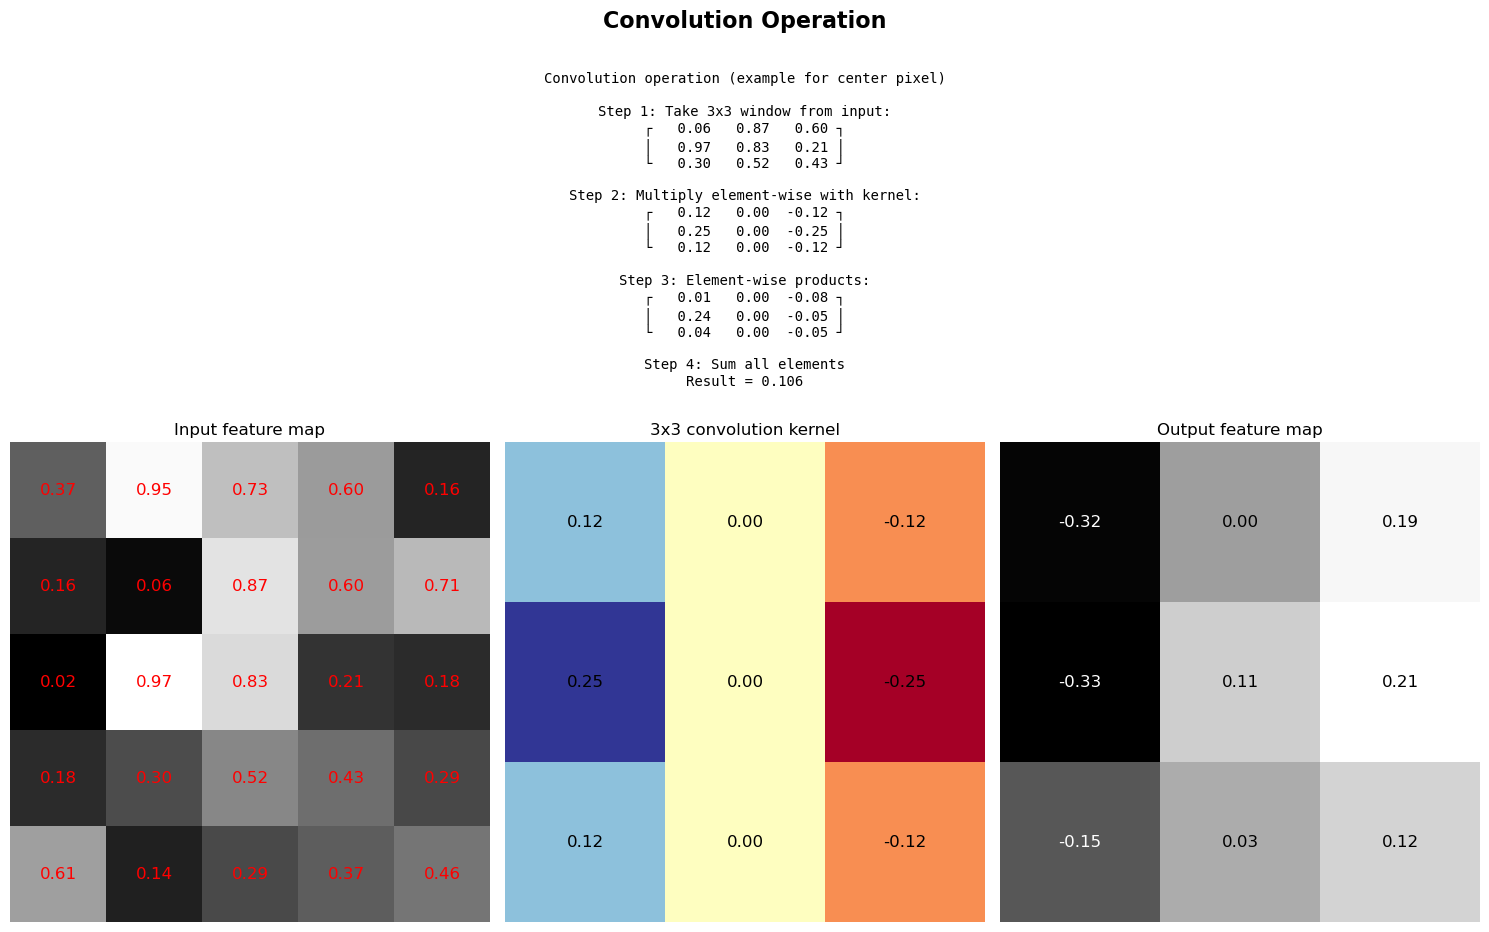

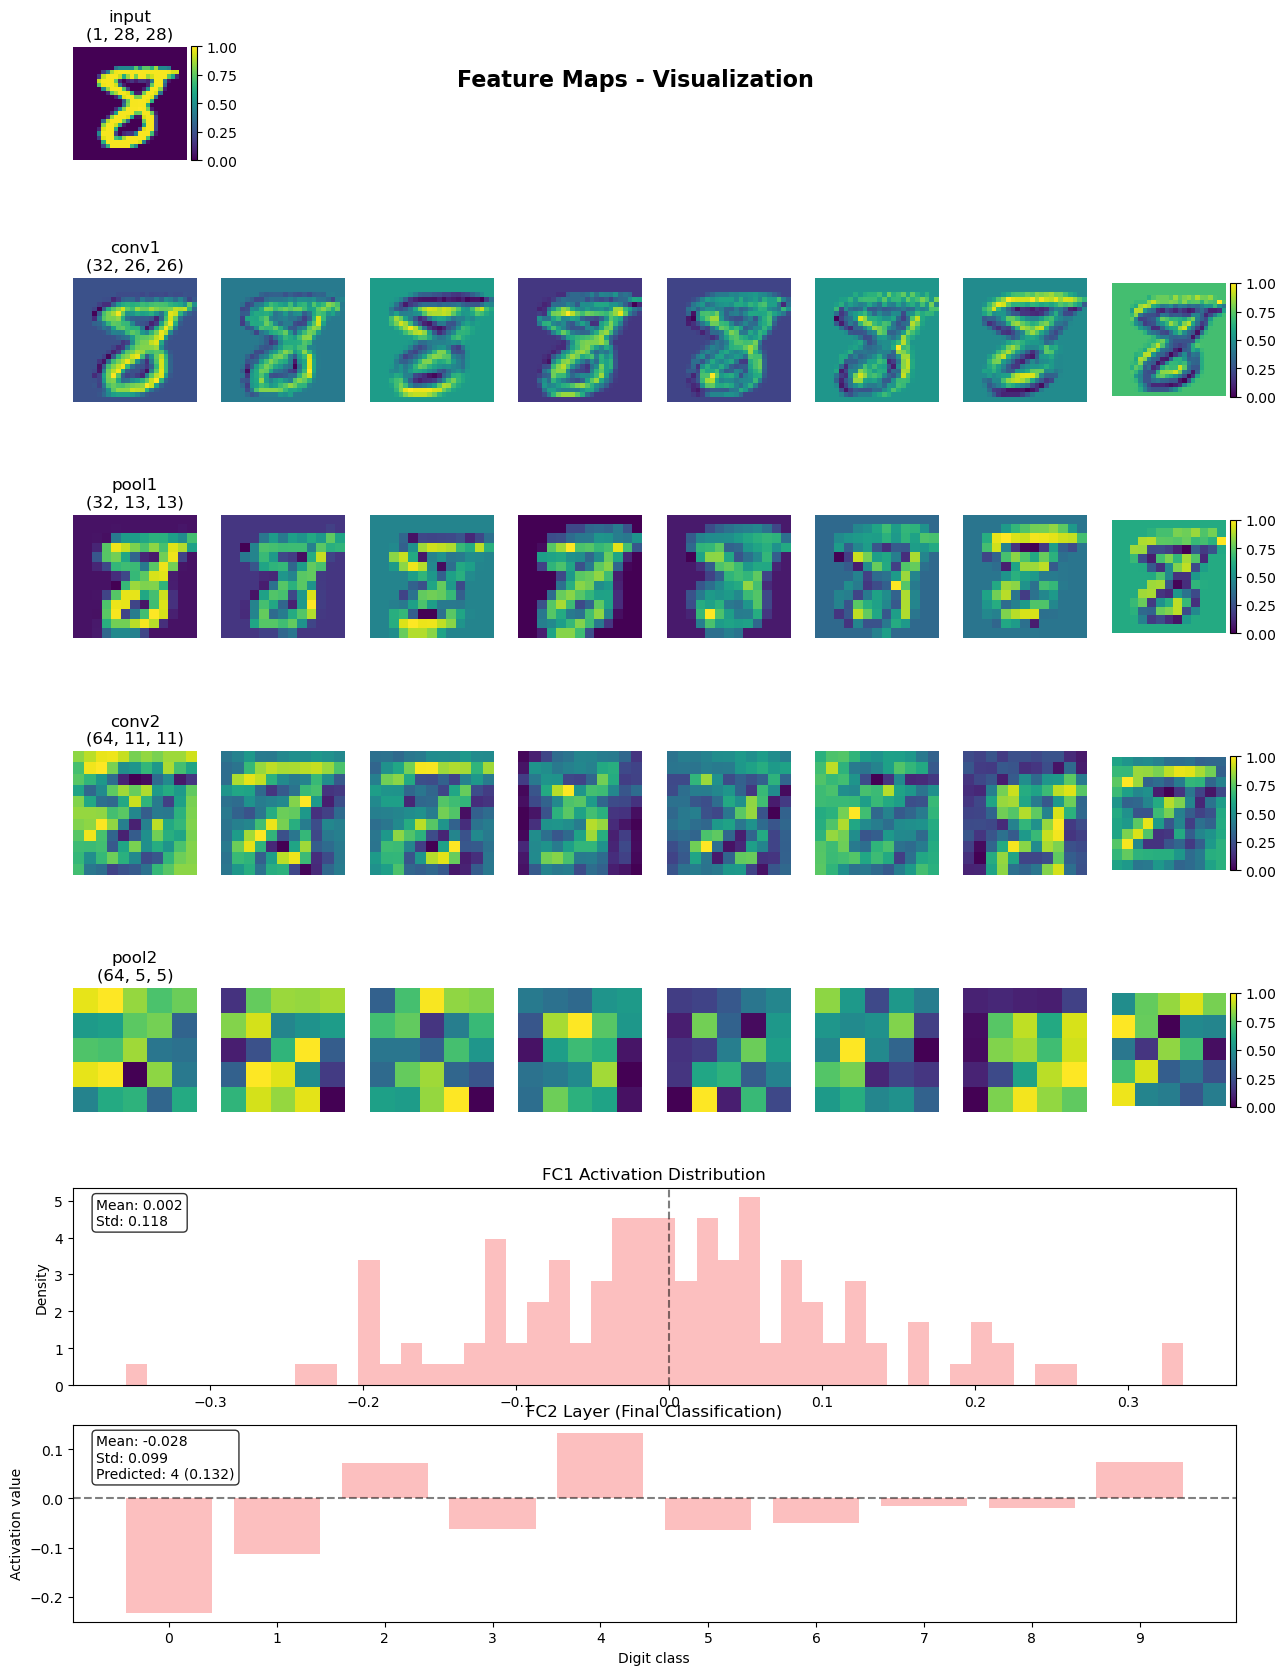

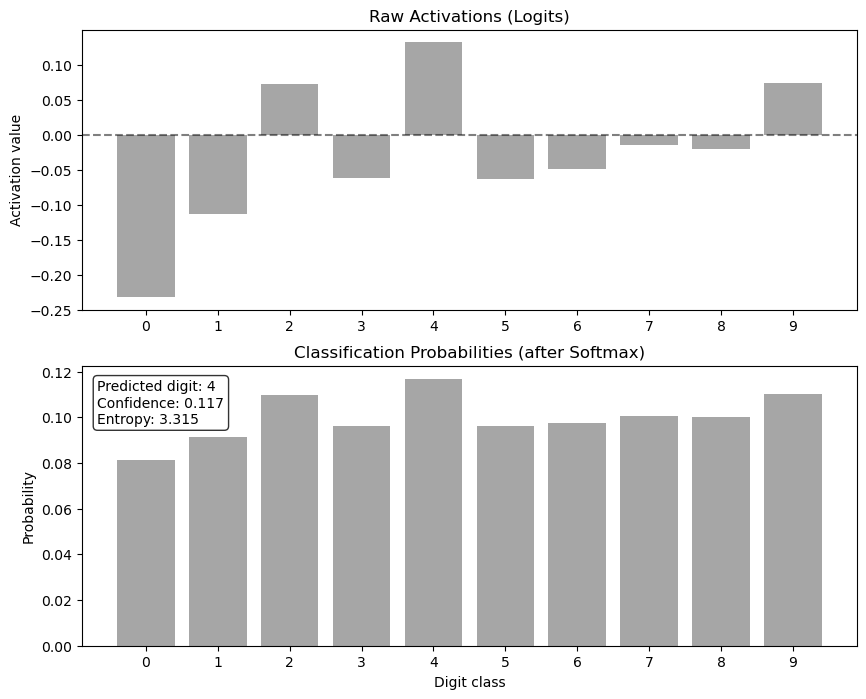

In [6]:
# === CNN model and visualization ===

class SimpleCNN(nn.Module):
    """Simple CNN architecture for MNIST classification."""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)  # 28x28x1 -> 26x26x32
        self.pool1 = nn.MaxPool2d(2, 2)   # 26x26x32 -> 13x13x32
        self.conv2 = nn.Conv2d(32, 64, 3) # 13x13x32 -> 11x11x64
        self.pool2 = nn.MaxPool2d(2, 2)   # 11x11x64 -> 5x5x64
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        layers = {}
        layers['input'] = x
        x = self.conv1(x)
        layers['conv1'] = x
        x = self.pool1(x)
        layers['pool1'] = x
        x = self.conv2(x)
        layers['conv2'] = x
        x = self.pool2(x)
        layers['pool2'] = x
        x = x.view(-1, 64 * 5 * 5)
        x = self.fc1(x)
        layers['fc1'] = x
        x = self.fc2(x)
        layers['fc2'] = x
        return x, layers


class CNNVisualizer:
    """Class for visualizing CNN architecture and feature maps."""
    
    def __init__(self):
        self.colors = {
            'input': '#e2e8f0',
            'conv': '#93c5fd',
            'pool': '#bfdbfe',
            'fc': '#fca5a5',
            'text': '#1e293b'
        }
        
    def draw_architecture(self, save_path=None):
        """Draw CNN architecture diagram."""
        fig = plt.figure(figsize=(15, 8))
        gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.3)
        ax_arch = fig.add_subplot(gs[0])
        ax_legend = fig.add_subplot(gs[1])
        
        # Layer configuration
        layer_list = [
            {'name': 'Input\n28x28x1', 'type': 'input', 'width': 1.0},
            {'name': 'Conv1\n26x26x32', 'type': 'conv', 'width': 1.2},
            {'name': 'Pool1\n13x13x32', 'type': 'pool', 'width': 0.8},
            {'name': 'Conv2\n11x11x64', 'type': 'conv', 'width': 1.2},
            {'name': 'Pool2\n5x5x64', 'type': 'pool', 'width': 0.8},
            {'name': 'FC\n128->10', 'type': 'fc', 'width': 1.0}
        ]
        
        # Draw layers
        x_offset = 1
        for i, layer in enumerate(layer_list):
            height = layer['width'] * 1.5
            width = layer['width']
            y_pos = (4 - height) / 2
            
            rect = patches.Rectangle(
                (x_offset, y_pos), width, height,
                facecolor=self.colors[layer['type']],
                edgecolor='black', alpha=0.7, linewidth=2
            )
            ax_arch.add_patch(rect)
            
            ax_arch.text(
                x_offset + width/2, y_pos + height/2, layer['name'],
                ha='center', va='center',
                color=self.colors['text'], fontsize=10, fontweight='bold'
            )
            
            if i < len(layer_list) - 1:
                arrow = FancyArrowPatch(
                    (x_offset + width, y_pos + height/2),
                    (x_offset + width + 1, y_pos + height/2),
                    arrowstyle='->', mutation_scale=20, color='gray'
                )
                ax_arch.add_patch(arrow)
            
            x_offset += width + 1
        
        ax_arch.set_xlim(0, x_offset)
        ax_arch.set_ylim(0, 4)
        ax_arch.axis('off')
        
        # Add legend
        legend_elements = [
            patches.Patch(facecolor=self.colors['input'], label='Input layer'),
            patches.Patch(facecolor=self.colors['conv'], label='Convolutional layer'),
            patches.Patch(facecolor=self.colors['pool'], label='Pooling layer'),
            patches.Patch(facecolor=self.colors['fc'], label='Fully connected layer')
        ]
        ax_legend.legend(handles=legend_elements, loc='center', ncol=4, frameon=False)
        ax_legend.axis('off')
        
        plt.suptitle('CNN Architecture for MNIST', fontsize=16, fontweight='bold', y=0.95)
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            
        return fig


    def visualize_classification(self, activations, save_path=None):
        """
        Visualize classification results from the FC2 layer.
        
        Args:
            activations: Raw activation values from the FC2 layer
            save_path: Path to save the visualization
        """
        # Convert to probabilities with softmax
        probabilities = torch.softmax(torch.tensor(activations), dim=0).numpy()
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[1, 1])
        
        # Plot raw activations
        x = np.arange(len(activations))
        ax1.bar(x, activations, alpha=0.7, color='gray')
        ax1.set_xticks(x)
        ax1.set_xticklabels([str(i) for i in range(10)])
        ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        ax1.set_title('Raw Activations (Logits)')
        ax1.set_ylabel('Activation value')
        
        # Plot probabilities
        ax2.bar(x, probabilities, alpha=0.7, color='gray')
        ax2.set_xticks(x)
        ax2.set_xticklabels([str(i) for i in range(10)])
        ax2.set_title('Classification Probabilities (after Softmax)')
        ax2.set_xlabel('Digit class')
        ax2.set_ylabel('Probability')
        
        # Add statistics
        predicted_digit = np.argmax(probabilities)
        max_probability = np.max(probabilities)
        entropy = -np.sum(probabilities * np.log2(probabilities + 1e-10))
        
        stats_text = (
            f'Predicted digit: {predicted_digit}\n'
            f'Confidence: {max_probability:.3f}\n'
            f'Entropy: {entropy:.3f}'
        )
        
        ax2.text(0.02, 0.95, stats_text, transform=ax2.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        return fig


    def visualize_feature_maps(self, model, input_image, save_path=None):
        """Visualize feature maps at each layer in the CNN."""
        model.eval()
        
        with torch.no_grad():
            _, feature_maps = model(input_image)
        
        n_layers = len(feature_maps)
        n_cols = 8
        fig = plt.figure(figsize=(15, 3 * n_layers))
        
        for idx, (layer_name, feature_map) in enumerate(feature_maps.items()):
            feature_map = feature_map.squeeze(0)
            
            if layer_name in ['fc1', 'fc2']:
                ax = plt.subplot(n_layers, 1, idx + 1)
                data = feature_map.numpy()

                if layer_name == 'fc2':
                    x = np.arange(len(data))
                    ax.bar(x, data, alpha=0.7, color=self.colors['fc'])
                    ax.set_xticks(x)
                    ax.set_xticklabels([str(i) for i in range(10)])
                    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
                    
                    mean = np.mean(data)
                    std = np.std(data)
                    max_digit = np.argmax(data)
                    max_value = np.max(data)
                    
                    stats_text = (
                        f'Mean: {mean:.3f}\n'
                        f'Std: {std:.3f}\n'
                        f'Predicted: {max_digit} ({max_value:.3f})'
                    )
                    
                    ax.text(0.02, 0.95, stats_text, transform=ax.transAxes,
                        verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                    
                    ax.set_title('FC2 Layer (Final Classification)')
                    ax.set_xlabel('Digit class')
                    ax.set_ylabel('Activation value')

                    class_fig = self.visualize_classification(data, 'classification.png')
                    
                else:
                    ax.hist(data, bins=50, density=True, alpha=0.7, color=self.colors['fc'])
                    ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
                    
                    mean = np.mean(data)
                    std = np.std(data)
                    ax.text(0.02, 0.95, 
                        f'Mean: {mean:.3f}\nStd: {std:.3f}',
                        transform=ax.transAxes, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                    
                    ax.set_title('FC1 Activation Distribution')
                    ax.set_ylabel('Density')
                
            else:
                n_filters = min(n_cols, feature_map.shape[0])
                for i in range(n_filters):
                    ax = plt.subplot(n_layers, n_cols, idx * n_cols + i + 1)
                    
                    fm = feature_map[i].numpy()
                    vmin, vmax = fm.min(), fm.max()
                    if vmin != vmax:
                        fm = (fm - vmin) / (vmax - vmin)
                    
                    im = ax.imshow(fm, cmap='viridis')
                    ax.axis('off')
                    
                    if i == 0:
                        ax.set_title(f'{layer_name}\n{tuple(feature_map.shape)}')
                    
                    if i == n_filters - 1:
                        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
                plt.suptitle('Feature Maps - Visualization', 
                        fontsize=16, fontweight='bold', y=0.85)
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        return fig  
     

    def visualize_convolution(self, save_path=None):
        """Visualize the convolution operation."""
        fig = plt.figure(figsize=(15, 10))
        gs = GridSpec(2, 3, height_ratios=[1, 2])
        
        ax_eq = fig.add_subplot(gs[0, :])
        ax1 = fig.add_subplot(gs[1, 0])
        ax2 = fig.add_subplot(gs[1, 1])
        ax3 = fig.add_subplot(gs[1, 2])
        
        np.random.seed(42)
        input_data = np.random.rand(5, 5)
        kernel = np.array([[1, 0, -1],
                          [2, 0, -2],
                          [1, 0, -1]]) / 8
        
        # Calculate output
        output = np.zeros((3, 3))
        for i in range(3):
            for j in range(3):
                output[i, j] = np.sum(input_data[i:i+3, j:j+3] * kernel)
        
        i, j = 1, 1
        window = input_data[i:i+3, j:j+3]
        result = output[i, j]
        products = window * kernel
        
        # Explanation with ASCII matrices
        eq_text = (
            "Convolution operation (example for center pixel)\n\n"
            "Step 1: Take 3x3 window from input:\n"
            f"┌ {window[0,0]:6.2f} {window[0,1]:6.2f} {window[0,2]:6.2f} ┐\n"
            f"│ {window[1,0]:6.2f} {window[1,1]:6.2f} {window[1,2]:6.2f} │\n"
            f"└ {window[2,0]:6.2f} {window[2,1]:6.2f} {window[2,2]:6.2f} ┘\n\n"
            "Step 2: Multiply element-wise with kernel:\n"
            f"┌ {kernel[0,0]:6.2f} {kernel[0,1]:6.2f} {kernel[0,2]:6.2f} ┐\n"
            f"│ {kernel[1,0]:6.2f} {kernel[1,1]:6.2f} {kernel[1,2]:6.2f} │\n"
            f"└ {kernel[2,0]:6.2f} {kernel[2,1]:6.2f} {kernel[2,2]:6.2f} ┘\n\n"
            "Step 3: Element-wise products:\n"
            f"┌ {products[0,0]:6.2f} {products[0,1]:6.2f} {products[0,2]:6.2f} ┐\n"
            f"│ {products[1,0]:6.2f} {products[1,1]:6.2f} {products[1,2]:6.2f} │\n"
            f"└ {products[2,0]:6.2f} {products[2,1]:6.2f} {products[2,2]:6.2f} ┘\n\n"
            "Step 4: Sum all elements\n"
            f"Result = {result:.3f}"
        )
        
        ax_eq.text(0.5, 0.5, eq_text, ha='center', va='center',
                transform=ax_eq.transAxes, fontsize=10, family='monospace')
        ax_eq.axis('off')
        
        # Plot input
        im1 = ax1.imshow(input_data, cmap='gray')
        for i in range(input_data.shape[0]):
            for j in range(input_data.shape[1]):
                ax1.text(j, i, f'{input_data[i, j]:.2f}',
                        ha='center', va='center', color='red', fontsize=12)
        ax1.set_title('Input feature map')
        ax1.axis('off')
        
        # Plot kernel
        im2 = ax2.imshow(kernel, cmap='RdYlBu')
        for i in range(kernel.shape[0]):
            for j in range(kernel.shape[1]):
                ax2.text(j, i, f'{kernel[i, j]:.2f}',
                        ha='center', va='center', color='black', fontsize=12)
        ax2.set_title('3x3 convolution kernel')
        ax2.axis('off')
        
        # Plot output
        im3 = ax3.imshow(output, cmap='gray')
        for i in range(output.shape[0]):
            for j in range(output.shape[1]):
                pixel_value = output[i, j]
                normalized = (pixel_value - output.min()) / (output.max() - output.min())
                text_color = 'white' if normalized < 0.5 else 'black'
                ax3.text(j, i, f'{pixel_value:.2f}',
                        ha='center', va='center', color=text_color, fontsize=12)
        ax3.set_title('Output feature map')
        ax3.axis('off')
        
        plt.suptitle('Convolution Operation', fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            
        return fig


# === Run visualization ===
if __name__ == "__main__":
    # Create visualizer
    visualizer = CNNVisualizer()
    
    # Draw and save architecture
    arch_fig = visualizer.draw_architecture(save_path='mnist_images/cnn_architecture.png')
    
    # Draw and save convolution operation
    conv_fig = visualizer.visualize_convolution(save_path='mnist_images/convolution.png')
    
    # Create model
    model = SimpleCNN()
    dummy_input = torch.randn(1, 1, 28, 28)  # Batch 1, 1 channel, 28x28

    # Load and preprocess the MNIST image
    if is_colab:
        import requests
        import io
        from PIL import Image

        url = 'https://raw.githubusercontent.com/arvidl/BMED365-2026/main/Lab2-DL/data/mnist_image_0000.png'
        response = requests.get(url, stream=True).raw
        image = Image.open(response)
        img = np.array(image)
    else:
        img_path = "../data/mnist_image_0000.png"
        img = plt.imread(img_path)
    
    # Convert RGBA to grayscale if necessary
    if len(img.shape) == 3:
        img = img[:, :, 0]
    
    # Convert to tensor and add batch and channel dimensions
    input_image = torch.from_numpy(img).float()
    input_image = input_image.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, 28, 28)
  
    # Visualize feature maps with MNIST image
    feature_fig = visualizer.visualize_feature_maps(
        model, input_image, save_path='mnist_images/feature_maps.png'
    )
    
    plt.show()

### Understanding the Feature Map Visualization

The visualization shows how the input image is transformed as it passes through different layers in the convolutional neural network (CNN). Let's go through each layer:

#### Input Layer
- Shows the original 28×28 grayscale image
- Single channel input (shape: 1×28×28)
- Random values in this case (from torch.randn)
- Displays the raw pixel intensities before any processing

#### Conv1 Layer
- First convolutional layer with 32 filters
- Output shape: 26×26×32 (reduced from 28×28 due to 3×3 kernel without padding)
- Each feature map shows different patterns/features learned by individual filters
- Some filters may activate on edges, others on textures or specific patterns

#### Pool1 Layer
- First max pooling layer (2×2 window with stride 2)
- Output shape: 13×13×32 (halved dimensions from Conv1)
- Preserves important features while reducing spatial dimensions
- Helps achieve spatial invariance and reduces computation

#### Conv2 Layer
- Second convolutional layer with 64 filters
- Output shape: 11×11×64
- Learns more complex features by combining patterns from Pool1
- Higher-level features compared to Conv1 (more abstract patterns)

#### Pool2 Layer
- Second max pooling layer
- Output shape: 5×5×64
- Further reduces spatial dimensions
- Maintains most important features for classification

#### FC1 Activation Distribution
- First fully connected layer (flattened Pool2 → 128 neurons)
- Shows histogram of activation values
- Mean and standard deviation indicate the spread of activations
- Distribution shape reveals how neurons are utilizing the activation space

#### FC2 Activation Distribution
- Final fully connected layer (128 → 10 neurons)
- Output corresponds to class probabilities (for MNIST digits 0-9)
- Distribution typically shows more distinct patterns as it's directly related to classification
- Mean and std values indicate the confidence and spread of predictions

The progression through these layers demonstrates how the network transforms from raw pixel data to increasingly abstract features, ultimately leading to classification outputs. The feature maps provide insights into what patterns each layer has learned to detect.


### Note on the FC2 Layer (Final Classification Layer)

In the FC2 layer (final classification layer), the decision-making process follows these steps:

1. **Raw Activations**: 
   - Each neuron outputs an activation value for digits 0-9
   - These values can be positive or negative
   - They are often called "logits" in this raw form

2. **Softmax Transformation**:
   - To convert these raw activations into probabilities, we apply the softmax function:
   ```python
      probabilities = torch.softmax(activations, dim=0)
   ```
   - Softmax formula: P(class_i) = exp(activation_i) / Σ(exp(activation_j))
   - This ensures:
     - All values are positive (0 to 1)
     - Sum of probabilities equals 1
     - Preserves relative ordering of activations

3. **Final Decision**:
   - The digit with the highest probability is chosen as the prediction
   - In code:



This visualization shows:
1. **Raw Activations**:
   - Positive and negative values
   - Relative strengths of each class
   - Zero baseline for reference

2. **Probabilities**:
   - Values between 0 and 1
   - Sum to 1.0
   - Easy to interpret as confidence scores
   - Entropy shows uncertainty in prediction

The network's decision is based on these probabilities, not the raw activations directly. A high positive activation generally leads to a high probability, but the softmax function considers the relative differences between all activations when computing the final probabilities. <br>Entropy: {-np.sum(probabilities * np.log2(probabilities + 1e-10)):.3f}

